In [49]:
import kagglehub
rahulkandwal19_neural_nexus_internal_round_path = kagglehub.dataset_download('rahulkandwal19/neural-nexus-internal-round')

print('Data source import complete.')

Using Colab cache for faster access to the 'neural-nexus-internal-round' dataset.
Data source import complete.


# **Neural Nexus Internal Round**
**Team Name : Attack On Data (F15DF5)**

# **Setup & Dataset Import**

In [50]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_path = os.path.join(rahulkandwal19_neural_nexus_internal_round_path, 'DATASET')

train_csv_path = os.path.join(base_path, 'Train.csv')
test_csv_path = os.path.join(base_path, 'Test.csv')

train_image_dir = os.path.join(base_path, 'train_images')
test_image_dir = os.path.join(base_path, 'test_images')

try:
    train_df = pd.read_csv(train_csv_path)
    test_df = pd.read_csv(test_csv_path)
    print("TRAIN.CSV and TEST.CSV loaded successfully")
except Exception as e:
    print("Error loading CSVs:", e)

print("Files in base path:", os.listdir(base_path))
print("Train images sample:", os.listdir(train_image_dir)[:5])
print("Test images sample:", os.listdir(test_image_dir)[:5])

TRAIN.CSV and TEST.CSV loaded successfully
Files in base path: ['train_images', 'Train.csv', 'Test.csv', 'test_images']
Train images sample: ['train_9590.png', 'train_9215.png', 'train_5097.png', 'train_14807.png', 'train_1117.png']
Test images sample: ['test_9989.png', 'test_5743.png', 'test_2343.png', 'test_6779.png', 'test_6689.png']


In [51]:
try:
    test_df = pd.read_csv(test_csv_path)
    train_df = pd.read_csv(train_csv_path)
    print("✅ TRAIN.CSV and TEST.CSV loaded successfully!")
except Exception as e:
    print("❌ Error loading CSVs:", e)

✅ TRAIN.CSV and TEST.CSV loaded successfully!


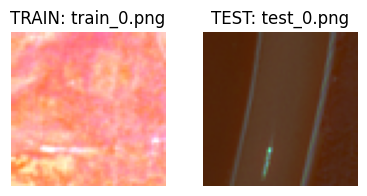

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

train_img_path = os.path.join(train_image_dir, train_df['IMAGE'].iloc[0])
sample_train_img = plt.imread(train_img_path)
axes[0].imshow(sample_train_img)
axes[0].set_title(f"TRAIN: {train_df['IMAGE'].iloc[0]}")
axes[0].axis("off")

test_img_path = os.path.join(test_image_dir, test_df['IMAGE'].iloc[0])
sample_test_img = plt.imread(test_img_path)
axes[1].imshow(sample_test_img)
axes[1].set_title(f"TEST: {test_df['IMAGE'].iloc[0]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [53]:
print("TRAIN SHAPE:", train_df.shape)
print("TEST SHAPE:", test_df.shape)
print("\nTRAIN COLUMNS:", train_df.columns.tolist())

if 'LABEL' in train_df.columns:
    print("\nCLASS DISTRIBUTION:")
    print(train_df['LABEL'].value_counts())
else:
    print("\nNo LABEL column found in train_df")

train_images = os.listdir(train_image_dir)
test_images = os.listdir(test_image_dir)

print("\nIMAGE COUNTS:")
print("Train images:", len(train_images))
print("Test images:", len(test_images))

missing_train = train_df[~train_df['IMAGE'].isin(train_images)]
missing_test = test_df[~test_df['IMAGE'].isin(test_images)]

print("\nMISSING FILES:")
print("Missing train images:", len(missing_train))
print("Missing test images:", len(missing_test))

print("\nDUPLICATES:")
print("Duplicate train rows:", train_df.duplicated().sum())
print("Duplicate test rows:", test_df.duplicated().sum())

print("\nSAMPLE TRAIN DATA:")
print(train_df.head())

print("\nSAMPLE TEST DATA:")
print(test_df.head())

TRAIN SHAPE: (16558, 2)
TEST SHAPE: (11039, 1)

TRAIN COLUMNS: ['IMAGE', 'LABEL']

CLASS DISTRIBUTION:
LABEL
SeaLake                 2167
AnnualCrop              1825
HerbaceousVegetation    1806
Residential             1790
Forest                  1776
River                   1509
PermanentCrop           1499
Highway                 1490
Industrial              1477
Pasture                 1219
Name: count, dtype: int64

IMAGE COUNTS:
Train images: 16558
Test images: 11039

MISSING FILES:
Missing train images: 0
Missing test images: 0

DUPLICATES:
Duplicate train rows: 0
Duplicate test rows: 0

SAMPLE TRAIN DATA:
         IMAGE                 LABEL
0  train_0.png  HerbaceousVegetation
1  train_1.png               Pasture
2  train_2.png           Residential
3  train_3.png               SeaLake
4  train_4.png               Highway

SAMPLE TEST DATA:
        IMAGE
0  test_0.png
1  test_1.png
2  test_2.png
3  test_3.png
4  test_4.png


# **Implementation & Training**

In [54]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [55]:
le = LabelEncoder()
train_df['LABEL_ENC'] = le.fit_transform(train_df['LABEL'])

train_split, val_split = train_test_split(
    train_df, test_size=0.2, stratify=train_df['LABEL_ENC'], random_state=42
)

In [56]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [57]:
class ImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, train=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'IMAGE']
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.train:
            label = self.df.loc[idx, 'LABEL_ENC']
            return image, label
        else:
            return image, img_name

In [58]:
train_dataset = ImageDataset(train_split, train_image_dir, train_transform, True)
val_dataset = ImageDataset(val_split, train_image_dir, val_transform, True)
test_dataset = ImageDataset(test_df, test_image_dir, val_transform, False)

# Updated batch size to 32 as requested
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [59]:
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 10)
model = model.to(device)
print("Switched to EfficientNet-B0 model.")

Switched to EfficientNet-B0 model.


In [60]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 28
print(f"Optimizer configured for EfficientNet-B0 (Adam, LR 1e-4).")

Optimizer configured for EfficientNet-B0 (Adam, LR 1e-4).


In [61]:
from tqdm import tqdm

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        bar.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Average Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/28: 100%|██████████| 414/414 [01:13<00:00,  5.62it/s, loss=0.859]


Epoch 1 Average Loss: 1.0001


Epoch 2/28: 100%|██████████| 414/414 [01:11<00:00,  5.81it/s, loss=0.502]


Epoch 2 Average Loss: 0.6208


Epoch 3/28: 100%|██████████| 414/414 [01:12<00:00,  5.71it/s, loss=0.999]


...

Epoch 26 Average Loss: 0.0749


Epoch 27/28: 100%|██████████| 414/414 [01:11<00:00,  5.76it/s, loss=0.0328]


Epoch 27 Average Loss: 0.0716


Epoch 28/28: 100%|██████████| 414/414 [01:12<00:00,  5.73it/s, loss=0.199]

Epoch 28 Average Loss: 0.0757


# **Generating Predections & FINAL.csv**

In [62]:
from google.colab import files

model.eval()
predictions = []
image_names = []

with torch.no_grad():
    for images, names in tqdm(test_loader, desc="Predicting"):
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels = le.inverse_transform(preds)
        predictions.extend(labels)
        image_names.extend(names)

submission = pd.DataFrame({"IMAGE": image_names, "LABEL": predictions})
submission.to_csv("FINAL.csv", index=False)
print("FINAL.csv generated using EfficientNet-B0 model!")

# Trigger file download
files.download('FINAL.csv')

Predicting: 100%|██████████| 345/345 [00:41<00:00,  8.32it/s]

FINAL.csv generated using EfficientNet-B0 model!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

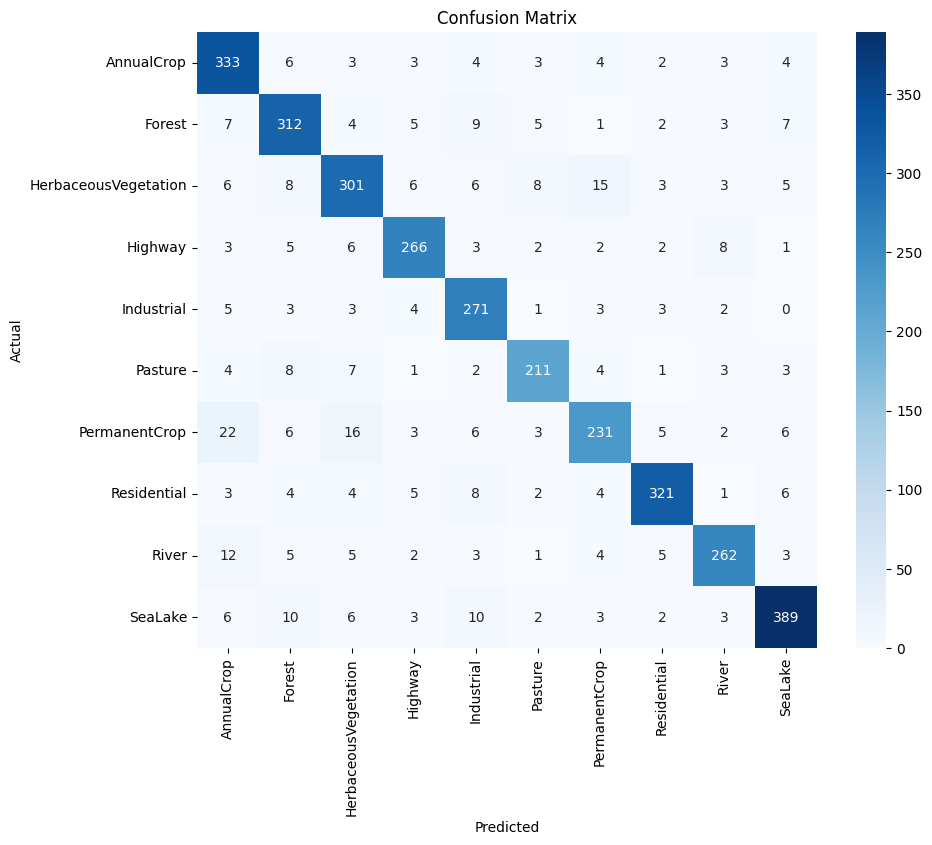

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [64]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Accuracy:", acc)
print("F1 Score:", f1)
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Accuracy: 0.8746980676328503
F1 Score: 0.8745478355742325

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.83      0.91      0.87       365
              Forest       0.85      0.88      0.86       355
HerbaceousVegetation       0.85      0.83      0.84       361
             Highway       0.89      0.89      0.89       298
          Industrial       0.84      0.92      0.88       295
             Pasture       0.89      0.86      0.88       244
       PermanentCrop       0.85      0.77      0.81       300
         Residential       0.93      0.90      0.91       358
               River       0.90      0.87      0.89       302
             SeaLake       0.92      0.90      0.91       434

            accuracy                           0.87      3312
           macro avg       0.88      0.87      0.87      3312
        weighted avg       0.88      0.87      0.87      3312



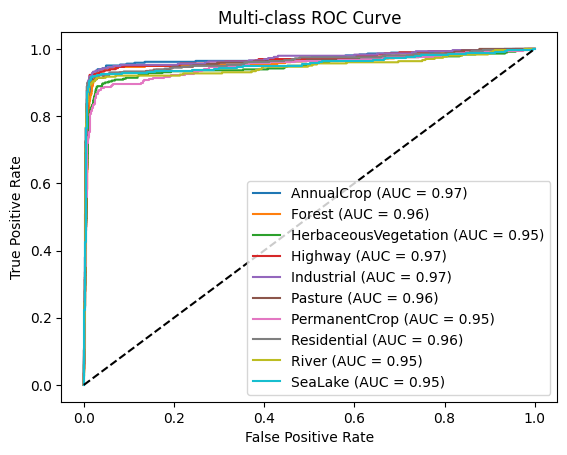

In [65]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

all_probs = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)

all_probs = np.array(all_probs)
all_labels_bin = label_binarize(all_labels, classes=range(len(le.classes_)))

plt.figure()

for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.show()

In [66]:
submission = test_df.copy()
submission['LABEL'] = predictions
submission.to_csv('FINAL.csv', index=False)

In [68]:
model.eval()
predictions = []
image_names = []

with torch.no_grad():
    for images, names in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        predictions.extend(preds + 1)
        image_names.extend(names)

submission = pd.DataFrame({
    "IMAGE": image_names,
    "LABEL": predictions
})

submission.to_csv("FINAL.csv", index=False)

print(submission.head())
print(submission.shape)

        IMAGE  LABEL
0  test_0.png      9
1  test_1.png      9
2  test_2.png      3
3  test_3.png      2
4  test_4.png      5
(11039, 2)


In [69]:
mapping = {i+1: label for i, label in enumerate(le.classes_)}

print("Label Mapping (Number → Class):")
for k, v in mapping.items():
    print(f"{k} → {v}")

Label Mapping (Number → Class):
1 → AnnualCrop
2 → Forest
3 → HerbaceousVegetation
4 → Highway
5 → Industrial
6 → Pasture
7 → PermanentCrop
8 → Residential
9 → River
10 → SeaLake


In [67]:
# Use Trained Model to Generate Predections on TEST.csv

# Example of Output .CSV
#-----------------------
# IMAGE          LABLE
# 000001.jpg	 1
# 000003.jpg	 2
# 000013.jpg	 3
# 000017.jpg	 4
#------------------------

#@ Follow Above Exact format for output file
#@ Name file exactly FINAL.csv and Columns as IMAGE and LABEL

# **Notebook Submission for [@Neural Nexus Internal Round](https://www.linkedin.com/posts/ieeesb-gehu_alrieeena26-ieee-machinelearning-activity-7434653027216764928-AwEY)**
## **Managed by [IEEE SB GEHU Dehradun](https://linktr.ee/IEEE_SB_GEHU)**